In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns

In [35]:
df=pd.read_csv("zameen.csv")

In [3]:
df

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168441,17355248,6754,https://www.zameen.com/Property/gulshan_e_maym...,House,26500000,Gadap Town,Karachi,Sindh,25.029909,67.137192,0,9.6 Marla,For Sale,6,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,9.6,5-10 Marla
168442,17355249,680,https://www.zameen.com/Property/gadap_town_gul...,House,12500000,Gadap Town,Karachi,Sindh,25.017951,67.136393,0,8 Marla,For Sale,3,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,8.0,5-10 Marla
168443,17355250,6757,https://www.zameen.com/Property/gulshan_e_maym...,House,27000000,Gadap Town,Karachi,Sindh,25.015384,67.116330,0,9.6 Marla,For Sale,6,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,9.6,5-10 Marla
168444,17355251,6752,https://www.zameen.com/Property/gulshan_e_maym...,House,11000000,Gadap Town,Karachi,Sindh,25.013265,67.120818,0,7.8 Marla,For Sale,3,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,7.8,5-10 Marla


In [113]:
df.dtypes

property_id        int64
location_id        int64
page_url          object
property_type     object
price              int64
location          object
city              object
province_name     object
latitude         float64
longitude        float64
baths              int64
area              object
purpose           object
bedrooms           int64
date_added        object
agency            object
agent             object
Area Type         object
Area Size        float64
Area Category     object
dtype: object

In [114]:
df.columns

Index(['property_id', 'location_id', 'page_url', 'property_type', 'price',
       'location', 'city', 'province_name', 'latitude', 'longitude', 'baths',
       'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent',
       'Area Type', 'Area Size', 'Area Category'],
      dtype='object')

In [33]:
df.describe()

,property_id,location_id,price,latitude,longitude,baths,bedrooms,Area Size
count,1.684460e+05,168446.000000,1.684460e+05,168446.000000,168446.000000,168446.000000,168446.000000,168446.000000
mean,1.559626e+07,4375.936395,1.776576e+07,29.859519,71.239804,2.874227,3.179422,5.892188
std,2.251207e+06,3776.561581,3.531003e+07,3.807870,3.133042,2.463400,1.971401,5.778327
min,8.657500e+04,1.000000,0.000000e+00,11.052446,25.906027,0.000000,0.000000,0.000000
25%,1.488320e+07,1058.000000,1.750000e+05,24.948536,67.130363,0.000000,2.000000,3.000000
50%,1.665851e+07,3286.000000,8.500000e+06,31.459784,73.056182,3.000000,3.000000,5.000000
75%,1.708662e+07,7220.000000,1.950000e+07,33.560887,73.259870,4.000000,4.000000,8.000000
max,1.735772e+07,14220.000000,2.000000e+09,73.184088,80.161430,403.000000,68.000000,800.000000


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  object 
 3   property_type  168446 non-null  object 
 4   price          168446 non-null  int64  
 5   location       168446 non-null  object 
 6   city           168446 non-null  object 
 7   province_name  168446 non-null  object 
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  object 
 12  purpose        168446 non-null  object 
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  object 
 15  agency         124375 non-null  object 
 16  agent          124374 non-null  object 
 17  Area Type      168446 non-nul

In [36]:
# remove unnecessary columns
df.drop(['location_id','page_url','location_id','property_type','province_name','latitude','longitude','purpose','date_added','agency'
        ,'agent','Area Type','Area Size','Area Category'],axis=1,inplace=True)

In [37]:
df

,property_id,price,location,city,baths,area,bedrooms
0,237062,10000000,G-10,Islamabad,2,4 Marla,2
1,346905,6900000,E-11,Islamabad,3,5.6 Marla,3
2,386513,16500000,G-15,Islamabad,6,8 Marla,5
3,656161,43500000,Bani Gala,Islamabad,4,2 Kanal,4
4,841645,7000000,DHA Defence,Islamabad,3,8 Marla,3
...,...,...,...,...,...,...,...
168441,17355248,26500000,Gadap Town,Karachi,0,9.6 Marla,6
168442,17355249,12500000,Gadap Town,Karachi,0,8 Marla,3
168443,17355250,27000000,Gadap Town,Karachi,0,9.6 Marla,6
168444,17355251,11000000,Gadap Town,Karachi,0,7.8 Marla,3


In [37]:
# Conver area to marla
def convert_to_marla(value):
    if pd.isna(value):
        return np.nan
    value=str(value).strip()
    match=re.search(r'\d+\.?\d*',value)
    if not match:
        return np.nan
    number=float(match.group())
    if "Kanal" in value:
        return number * 20
    elif "Marla" in value:
        return number
    else:
        return np.nan
df['area']=df['area'].apply(convert_to_marla)

In [39]:
df

,property_id,price,location,city,baths,area,bedrooms
0,237062,10000000,G-10,Islamabad,2,4.0,2
1,346905,6900000,E-11,Islamabad,3,5.6,3
2,386513,16500000,G-15,Islamabad,6,8.0,5
3,656161,43500000,Bani Gala,Islamabad,4,40.0,4
4,841645,7000000,DHA Defence,Islamabad,3,8.0,3
...,...,...,...,...,...,...,...
168441,17355248,26500000,Gadap Town,Karachi,0,9.6,6
168442,17355249,12500000,Gadap Town,Karachi,0,8.0,3
168443,17355250,27000000,Gadap Town,Karachi,0,9.6,6
168444,17355251,11000000,Gadap Town,Karachi,0,7.8,3


In [40]:
df.isnull().sum()

property_id    0
price          0
location       0
city           0
baths          0
area           0
bedrooms       0
dtype: int64

In [38]:
df.rename(columns={'area': 'area in marla'}, inplace=True)

In [39]:
df

,property_id,price,location,city,baths,area in marla,bedrooms
0,237062,10000000,G-10,Islamabad,2,4.0,2
1,346905,6900000,E-11,Islamabad,3,5.6,3
2,386513,16500000,G-15,Islamabad,6,8.0,5
3,656161,43500000,Bani Gala,Islamabad,4,40.0,4
4,841645,7000000,DHA Defence,Islamabad,3,8.0,3
...,...,...,...,...,...,...,...
168441,17355248,26500000,Gadap Town,Karachi,0,9.6,6
168442,17355249,12500000,Gadap Town,Karachi,0,8.0,3
168443,17355250,27000000,Gadap Town,Karachi,0,9.6,6
168444,17355251,11000000,Gadap Town,Karachi,0,7.8,3


In [40]:
# select only houses whose area is 0 <area<=100
df=df[(df["area in marla"] >0) & (df["area in marla"] <=100)]

In [45]:
df

,property_id,price,location,city,baths,area in marla,bedrooms
0,237062,10000000,G-10,Islamabad,2,4.0,2
1,346905,6900000,E-11,Islamabad,3,5.6,3
2,386513,16500000,G-15,Islamabad,6,8.0,5
3,656161,43500000,Bani Gala,Islamabad,4,40.0,4
4,841645,7000000,DHA Defence,Islamabad,3,8.0,3
...,...,...,...,...,...,...,...
168441,17355248,26500000,Gadap Town,Karachi,0,9.6,6
168442,17355249,12500000,Gadap Town,Karachi,0,8.0,3
168443,17355250,27000000,Gadap Town,Karachi,0,9.6,6
168444,17355251,11000000,Gadap Town,Karachi,0,7.8,3


In [46]:
df['area in marla'].describe()

count    167855.000000
mean         10.197442
std           9.433349
min           0.100000
25%           4.800000
50%           7.000000
75%          12.000000
max         100.000000
Name: area in marla, dtype: float64

In [47]:
df[df["location"].isin(rare_locations)].shape

(0, 7)

In [48]:
df['baths'].describe()

count    167855.000000
mean          2.874469
std           2.461100
min           0.000000
25%           0.000000
50%           3.000000
75%           4.000000
max         403.000000
Name: baths, dtype: float64

In [49]:
df[df['baths'] ==0]

,property_id,price,location,city,baths,area in marla,bedrooms
12,1623818,400000000,F-6,Islamabad,0,90.0,0
19,2384979,1750000,PWD Housing Scheme,Islamabad,0,1.5,0
49,555962,9500000,Eden,Lahore,0,9.0,3
54,983065,32500000,EME Society,Lahore,0,20.0,5
55,983066,31500000,EME Society,Lahore,0,20.0,6
...,...,...,...,...,...,...,...
168440,17355247,4800000,Gadap Town,Karachi,0,3.8,2
168441,17355248,26500000,Gadap Town,Karachi,0,9.6,6
168442,17355249,12500000,Gadap Town,Karachi,0,8.0,3
168443,17355250,27000000,Gadap Town,Karachi,0,9.6,6


In [50]:
df[df['bedrooms'] ==0]

,property_id,price,location,city,baths,area in marla,bedrooms
12,1623818,400000000,F-6,Islamabad,0,90.0,0
19,2384979,1750000,PWD Housing Scheme,Islamabad,0,1.5,0
60,1646880,18500000,Bahria Town,Lahore,0,10.0,0
83,3051476,65000000,Valencia Housing Society,Lahore,0,40.0,0
86,3242351,66500000,Valencia Housing Society,Lahore,0,40.0,0
...,...,...,...,...,...,...,...
168366,17355428,12900000,Bankers Co-operative Housing Society,Lahore,0,5.0,0
168383,17356216,28000,Johar Town,Lahore,0,5.0,0
168393,17354543,6000000,Adiala Road,Rawalpindi,0,5.0,0
168402,17355396,13000000,Adiala Road,Rawalpindi,0,10.0,0


In [51]:
df[df['baths'] == df['baths'].max()]

,property_id,price,location,city,baths,area in marla,bedrooms
129605,17101832,15000000,Khayaban-e-Sir Syed,Rawalpindi,403,5.0,6


In [52]:
# check wrong entries like in this out come 403 baths in 5 marla plot that is impossible
df[df['baths'] > 15]

,property_id,price,location,city,baths,area in marla,bedrooms
129605,17101832,15000000,Khayaban-e-Sir Syed,Rawalpindi,403,5.0,6


In [41]:
# remove wrong entry
df = df[df['baths'] != 403]

In [42]:
# this location has wrong entries therefore we remove this
df = df[df['location'] != "PWD Road"]

In [43]:
# this location is government property
df = df[df['location'] != "Labor Colony"]

In [44]:
# remove rows where bedrooms and baths both are zero
df = df[~((df['bedrooms'] == 0) & (df['baths'] == 0))]

In [45]:
# we also remove entries where bath is zero
df = df[df['baths'] != 0]

In [12]:
df[df["location"]=="Others"].shape

(51, 7)

In [46]:
df = df[df['location'] != "Others"]

In [47]:
# check entries are removed where bed and bath both are zero
df[(df['bedrooms'] == 0) & (df['baths'] == 0)].shape

(0, 7)

In [48]:
df[df["location"]=="Others"].shape

(0, 7)

In [60]:
df.describe()

,property_id,price,baths,area in marla,bedrooms
count,1.255880e+05,1.255880e+05,125588.000000,125588.000000,125588.000000
mean,1.543789e+07,1.782534e+07,3.835908,10.215682,3.655365
std,2.323755e+06,3.129853e+07,1.767125,9.109281,1.611106
min,8.657500e+04,1.000000e+00,1.000000,0.100000,0.000000
25%,1.460562e+07,3.500000e+05,3.000000,4.800000,3.000000
50%,1.645953e+07,9.200000e+06,3.000000,7.600000,3.000000
75%,1.705305e+07,2.000000e+07,5.000000,12.000000,5.000000
max,1.735772e+07,1.000000e+09,14.000000,100.000000,18.000000


In [61]:
df

,property_id,price,location,city,baths,area in marla,bedrooms
0,237062,10000000,G-10,Islamabad,2,4.0,2
1,346905,6900000,E-11,Islamabad,3,5.6,3
2,386513,16500000,G-15,Islamabad,6,8.0,5
3,656161,43500000,Bani Gala,Islamabad,4,40.0,4
4,841645,7000000,DHA Defence,Islamabad,3,8.0,3
...,...,...,...,...,...,...,...
168436,17354114,8800000,Bahria Town Karachi,Karachi,4,8.0,3
168437,17354117,5000000,Bahria Town Karachi,Karachi,4,5.0,3
168438,17354433,14000000,Bahria Town Karachi,Karachi,3,8.0,3
168439,17355068,14000000,Bahria Town Karachi,Karachi,4,14.0,4


In [49]:
location_counts=df.groupby(['city','location']).size()
location_counts

city        location                   
Faisalabad  204 Chak Road                    8
            Abdullah City                    2
            Abdullahpur                      8
            Afghanabad                       3
            Ahmadabad                       12
                                          ... 
Rawalpindi  Westridge                      123
            Wireless Residential Colony      1
            Yousaf Colony                   15
            Zafar ul Haq Road                1
            Zeeshan Colony                   3
Length: 1507, dtype: int64

In [50]:
# rare locations means whose locations where number of plots are rare mean very less
rare_locations=location_counts[location_counts <20].index
rare_locations

MultiIndex([('Faisalabad',               '204 Chak Road'),
            ('Faisalabad',               'Abdullah City'),
            ('Faisalabad',                 'Abdullahpur'),
            ('Faisalabad',                  'Afghanabad'),
            ('Faisalabad',                   'Ahmadabad'),
            ('Faisalabad',             'Air Avenue City'),
            ('Faisalabad',                 'Akbar Chowk'),
            ('Faisalabad',                'Akbar Colony'),
            ('Faisalabad',            'Al Barkat Villas'),
            ('Faisalabad',             'Al Fayaz Colony'),
            ...
            ('Rawalpindi',           'Transformer Chowk'),
            ('Rawalpindi',                       'Tulsa'),
            ('Rawalpindi',               'Wah Link Road'),
            ('Rawalpindi',                'Walait Homes'),
            ('Rawalpindi',                  'Waris Khan'),
            ('Rawalpindi',                  'Wazir Town'),
            ('Rawalpindi', 'Wireless Res

In [21]:
len(rare_locations)

1127

In [51]:
df_clean=df[~df.set_index(["city","location"]).index.isin(rare_locations)]
df_clean

,property_id,price,location,city,baths,area in marla,bedrooms
0,237062,10000000,G-10,Islamabad,2,4.0,2
1,346905,6900000,E-11,Islamabad,3,5.6,3
2,386513,16500000,G-15,Islamabad,6,8.0,5
3,656161,43500000,Bani Gala,Islamabad,4,40.0,4
4,841645,7000000,DHA Defence,Islamabad,3,8.0,3
...,...,...,...,...,...,...,...
168436,17354114,8800000,Bahria Town Karachi,Karachi,4,8.0,3
168437,17354117,5000000,Bahria Town Karachi,Karachi,4,5.0,3
168438,17354433,14000000,Bahria Town Karachi,Karachi,3,8.0,3
168439,17355068,14000000,Bahria Town Karachi,Karachi,4,14.0,4


In [91]:
total_rows=df_clean.shape[0]
unique_ids=df_clean['property_id'].nunique()
print("Total rows:", total_rows)
print("unique_property_id:", unique_ids)

Total rows: 119239
unique_property_id: 119239


In [66]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119239 entries, 0 to 168445
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    119239 non-null  int64  
 1   price          119239 non-null  int64  
 2   location       119239 non-null  object 
 3   city           119239 non-null  object 
 4   baths          119239 non-null  int64  
 5   area in marla  119239 non-null  float64
 6   bedrooms       119239 non-null  int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 7.3+ MB


In [67]:
df_clean.describe()

,property_id,price,baths,area in marla,bedrooms
count,1.192390e+05,1.192390e+05,119239.000000,119239.000000,119239.000000
mean,1.550521e+07,1.814811e+07,3.852280,10.349332,3.651331
std,2.286179e+06,3.179039e+07,1.770046,9.098772,1.599727
min,8.657500e+04,1.000000e+00,1.000000,0.100000,0.000000
25%,1.472916e+07,2.800000e+05,3.000000,4.900000,3.000000
50%,1.653418e+07,9.500000e+06,3.000000,8.000000,3.000000
75%,1.706017e+07,2.080000e+07,5.000000,12.000000,5.000000
max,1.735772e+07,1.000000e+09,14.000000,100.000000,18.000000


In [52]:
# Divide price by 1,000,00 to convert to lakhs
df_clean['price'] = df_clean['price'] / 100000

C:\Users\shake\AppData\Local\Temp\ipykernel_13928\4165258778.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['price'] = df_clean['price'] / 100000


In [20]:
df_clean

,property_id,price,location,city,baths,area in marla,bedrooms
0,237062,100.0,G-10,Islamabad,2,4.0,2
1,346905,69.0,E-11,Islamabad,3,5.6,3
2,386513,165.0,G-15,Islamabad,6,8.0,5
3,656161,435.0,Bani Gala,Islamabad,4,40.0,4
4,841645,70.0,DHA Defence,Islamabad,3,8.0,3
...,...,...,...,...,...,...,...
168436,17354114,88.0,Bahria Town Karachi,Karachi,4,8.0,3
168437,17354117,50.0,Bahria Town Karachi,Karachi,4,5.0,3
168438,17354433,140.0,Bahria Town Karachi,Karachi,3,8.0,3
168439,17355068,140.0,Bahria Town Karachi,Karachi,4,14.0,4


In [53]:
df_clean.to_csv("cleaned_house_data.csv", index=False)

In [54]:
cleaned_data=pd.read_csv("cleaned_house_data.csv")
cleaned_data

,property_id,price,location,city,baths,area in marla,bedrooms
0,237062,100.0,G-10,Islamabad,2,4.0,2
1,346905,69.0,E-11,Islamabad,3,5.6,3
2,386513,165.0,G-15,Islamabad,6,8.0,5
3,656161,435.0,Bani Gala,Islamabad,4,40.0,4
4,841645,70.0,DHA Defence,Islamabad,3,8.0,3
...,...,...,...,...,...,...,...
119192,17354114,88.0,Bahria Town Karachi,Karachi,4,8.0,3
119193,17354117,50.0,Bahria Town Karachi,Karachi,4,5.0,3
119194,17354433,140.0,Bahria Town Karachi,Karachi,3,8.0,3
119195,17355068,140.0,Bahria Town Karachi,Karachi,4,14.0,4


In [55]:
cleaned_data["location"].nunique()

375

#### Exploratory data analysis

In [56]:
# average price of houses at each location and each city
avg_price_per_location=cleaned_data.groupby(['city','location'], as_index=False)['price'].mean()
avg_price_per_location

,city,location,price
0,Faisalabad,Al Najaf Colony,37.990000
1,Faisalabad,Al Noor Garden,80.255758
2,Faisalabad,Amin Town,88.571591
3,Faisalabad,Canal Road,102.891834
4,Faisalabad,Eden Gardens,51.132657
...,...,...,...
382,Rawalpindi,Shams Abad,68.284545
383,Rawalpindi,Sher Zaman Colony,134.575714
384,Rawalpindi,Tench Bhata,62.605000
385,Rawalpindi,Tulsa Road,122.646622


In [57]:
# most expensive location in each city
expensive_location_per_city=avg_price_per_location.loc[avg_price_per_location.groupby('city')['price'].idxmax()]
expensive_location_per_city

,city,location,price
20,Faisalabad,Peoples Colony No 1,155.570789
47,Islamabad,E-7,511.358000
175,Karachi,Zamzama,828.001020
278,Lahore,New Muslim Town,747.344828
386,Rawalpindi,Westridge,211.956504


In [98]:
cleaned_data[['price', 'area in marla','baths','bedrooms']].corr()

,price,area in marla,baths,bedrooms
price,1.000000,0.536784,0.450336,0.437978
area in marla,0.536784,1.000000,0.530047,0.508684
baths,0.450336,0.530047,1.000000,0.885312
bedrooms,0.437978,0.508684,0.885312,1.000000


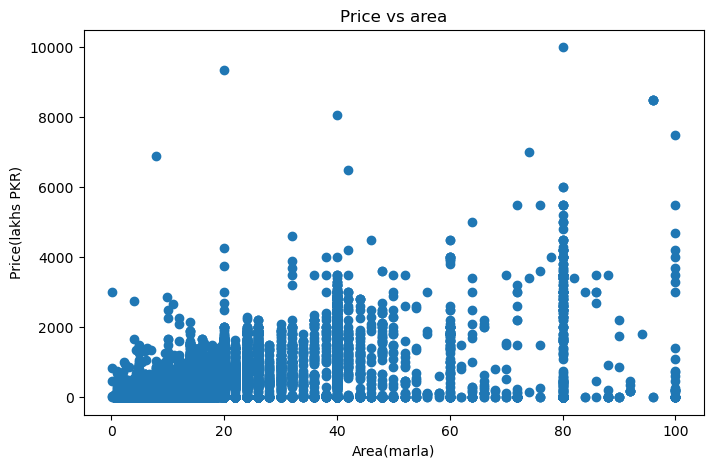

In [58]:
plt.figure(figsize=(8,5))
plt.scatter(cleaned_data['area in marla'],cleaned_data['price'])
plt.xlabel('Area(marla)')
plt.ylabel('Price(lakhs PKR)')
plt.title("Price vs area")
plt.show()

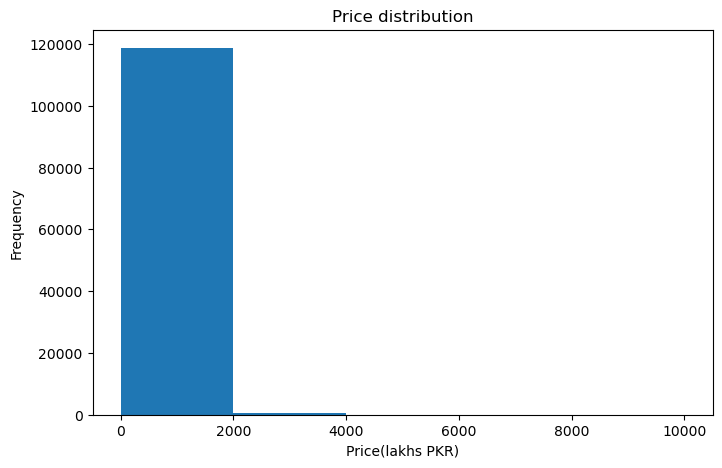

In [59]:
plt.figure(figsize=(8,5))
plt.hist(cleaned_data['price'], bins=5)
plt.xlabel('Price(lakhs PKR)')
plt.ylabel('Frequency')
plt.title("Price distribution")
plt.show()

## Lahore data analysis

In [101]:
lahore_cleaned_data=cleaned_data[cleaned_data['city']=='Lahore']

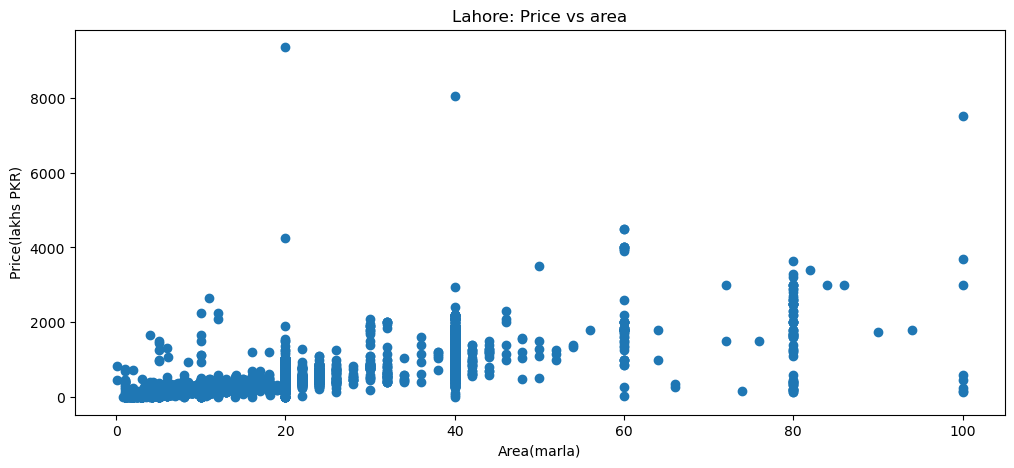

In [102]:
plt.figure(figsize=(12,5))
plt.scatter(lahore_cleaned_data['area in marla'],lahore_cleaned_data['price'])
plt.xlabel('Area(marla)')
plt.ylabel('Price(lakhs PKR)')
plt.title("Lahore: Price vs area")
plt.show()

In [103]:
# top 5 expensive locations in lahore
top_5_expensive_L=(lahore_cleaned_data.groupby(["location"])["price"].mean().sort_values(ascending=False).head(5))
top_5_expensive_L

location
New Muslim Town    747.344828
Model Town         724.427844
Gulberg            565.740971
Iqbal Avenue       510.820513
DHA Defence        481.225891
Name: price, dtype: float64

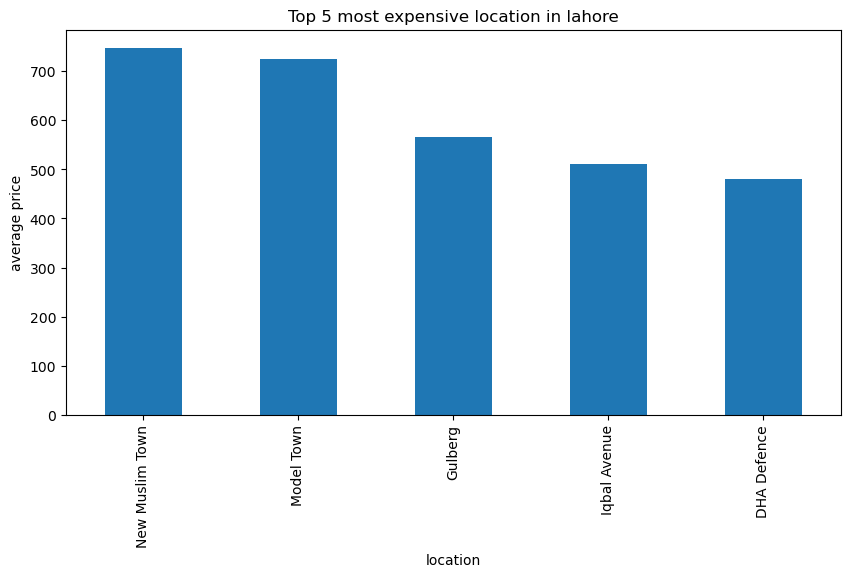

In [104]:
top_5_expensive_L.plot(kind="bar", figsize=(10,5))
plt.title("Top 5 most expensive location in lahore")
plt.ylabel("average price")
plt.show()

In [105]:
top_5_cheapest_L=(lahore_cleaned_data.groupby(["location"])["price"].mean().sort_values().head(5))
top_5_cheapest_L

location
Ashiana-e-Quaid Housing Scheme    30.080000
Lahore - Islamabad Motorway       33.009524
Omega Homes                       36.273333
Sharaqpur Road                    38.720588
Kahna                             39.921875
Name: price, dtype: float64

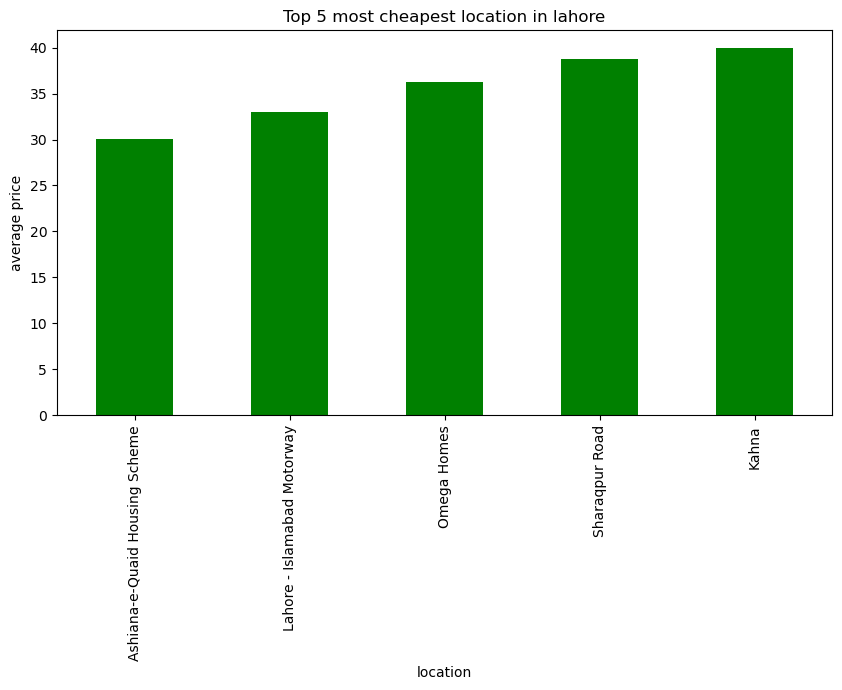

In [106]:
top_5_cheapest_L.plot(kind="bar", figsize=(10,5), color="green")
plt.title("Top 5 most cheapest location in lahore")
plt.ylabel("average price")
plt.show()

In [114]:
# average price per location and highest location in lahore
location_price=lahore_cleaned_data.groupby("location")["price"].mean()
# get highest and lowest price location
highest_location=location_price.idxmax()
lowest_location=location_price.idxmin()
# average price of one canal house
one_canal_high=lahore_cleaned_data[(lahore_cleaned_data["location"]==highest_location) & (lahore_cleaned_data["area in marla"]==20)]["price"].mean()
one_canal_low=lahore_cleaned_data[(lahore_cleaned_data["location"]==lowest_location) & (lahore_cleaned_data["area in marla"]==20)]["price"].mean()
print("Highest price location:", highest_location, one_canal_high)
print("lowest price location:", lowest_location, one_canal_low)

Highest price location: New Muslim Town 533.125
lowest price location: Ashiana-e-Quaid Housing Scheme nan


In [115]:
# average price per marla and highest location
lahore_cleaned_data["price_per_marla"]=(lahore_cleaned_data["price"]/lahore_cleaned_data["area in marla"])
location_ppm=lahore_cleaned_data.groupby("location")["price_per_marla"].mean()
highest_location=location_ppm.idxmax()
highest_price=location_ppm.max()
lowest_location=location_ppm.idxmin()
lowest_price=location_ppm.min()
print(f"Highest price per marla: {highest_location}: {highest_price:.2f}")
print(f"lowest price per marla: {lowest_location}: {lowest_price:.2f}")

Highest price per marla: Walled City: 46.70
lowest price per marla: Elite Town: 9.51


C:\Users\shake\AppData\Local\Temp\ipykernel_8868\4103744075.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lahore_cleaned_data["price_per_marla"]=(lahore_cleaned_data["price"]/lahore_cleaned_data["area in marla"])


In [116]:
# average price per marla at each location
lahore_cleaned_data["price_per_marla"]=(lahore_cleaned_data["price"]/lahore_cleaned_data["area in marla"])
location_ppm_df=lahore_cleaned_data.groupby("location")["price_per_marla"].mean().reset_index()
location_ppm_df.columns=["location","Average price per marla"]
location_ppm_df=location_ppm_df.sort_values(by="Average price per marla",ascending=False)
location_ppm_df

C:\Users\shake\AppData\Local\Temp\ipykernel_8868\4029917428.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lahore_cleaned_data["price_per_marla"]=(lahore_cleaned_data["price"]/lahore_cleaned_data["area in marla"])


,location,Average price per marla
152,Walled City,46.695534
72,Islampura,29.751422
40,DHA Defence,29.750372
61,Gulberg,28.678236
146,Tariq Gardens,28.491930
...,...,...
81,Lahore - Islamabad Motorway,10.042857
121,Rana Town,10.006623
84,Lahore Motorway City,9.818326
79,Khayaban-e-Amin,9.601545


In [117]:
lahore_cleaned_data[['price', 'area in marla','baths','bedrooms', 'price_per_marla']].corr()

,price,area in marla,baths,bedrooms,price_per_marla
price,1.000000,0.820996,0.507181,0.501846,0.096193
area in marla,0.820996,1.000000,0.568510,0.572650,0.003661
baths,0.507181,0.568510,1.000000,0.844589,0.047411
bedrooms,0.501846,0.572650,0.844589,1.000000,0.036636
price_per_marla,0.096193,0.003661,0.047411,0.036636,1.000000


### Price of one canal home in lahore different areas

In [118]:
one_canal=lahore_cleaned_data[lahore_cleaned_data["area in marla"]==20]
one_canal

,property_id,price,location,city,baths,area in marla,bedrooms,price_per_marla
40,482892,400.0,Multan Road,Lahore,5,20.0,5,20.00
41,562843,1250.0,Gulberg,Lahore,7,20.0,8,62.50
43,785289,520.0,Gulberg,Lahore,6,20.0,5,26.00
47,1861954,225.0,Bedian Road,Lahore,4,20.0,4,11.25
50,2311887,450.0,Askari,Lahore,6,20.0,5,22.50
...,...,...,...,...,...,...,...,...
119221,17357276,390.0,DHA Defence,Lahore,6,20.0,5,19.50
119222,17357313,280.0,Lake City,Lahore,7,20.0,6,14.00
119224,17357587,440.0,DHA Defence,Lahore,7,20.0,6,22.00
119225,17357646,550.0,DHA Defence,Lahore,6,20.0,5,27.50


### Ashiana-e-Quaid Housing Scheme prices compare to other locations

In [119]:
# Ashiana-e-Quaid Housing Scheme prices (price per location) compare to others
Ashiana_e_Quaid_Housing_Scheme_price=lahore_cleaned_data[lahore_cleaned_data["location"]=="Ashiana-e-Quaid Housing Scheme"]["price"].mean()
overall_avg=lahore_cleaned_data["price"].mean()
print("Ashiana-e-Quaid Housing Scheme average price:", Ashiana_e_Quaid_Housing_Scheme_price)
print("Overall average average price:", overall_avg)

Ashiana-e-Quaid Housing Scheme average price: 30.08
Overall average average price: 252.14747367303545


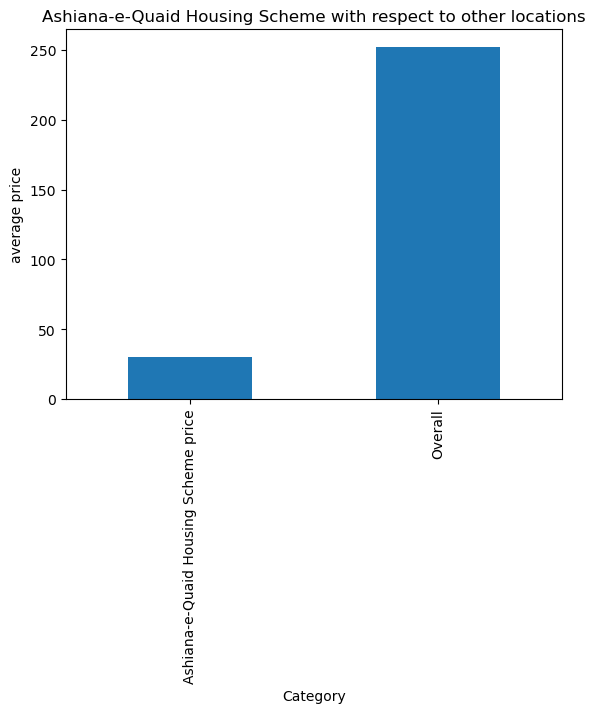

In [120]:
comparison=pd.DataFrame({
    "Category":["Ashiana-e-Quaid Housing Scheme price", "Overall"],
    "Average price": [Ashiana_e_Quaid_Housing_Scheme_price, overall_avg]})
comparison.plot(kind="bar", x="Category", y="Average price",legend=False)
plt.title("Ashiana-e-Quaid Housing Scheme with respect to other locations")
plt.ylabel("average price")
plt.show()

### Elite Town prices(prices per marla) compare to other locations

In [124]:
#  Elite Town prices (price per marla) compare to others
Elite_Town=lahore_cleaned_data[lahore_cleaned_data["location"]=="Elite Town"]["price_per_marla"].mean()
overall_avg=lahore_cleaned_data["price_per_marla"].mean()
print("Elite Town average price per marla:", Elite_Town)
print("Overall average price per marla:", overall_avg)

Elite Town average price per marla: 9.5136544011544
Overall average price per marla: 22.69742816503592


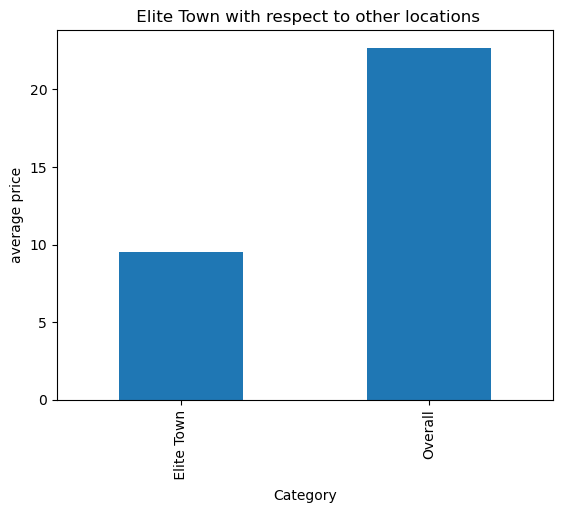

In [125]:
comparison=pd.DataFrame({
    "Category":[" Elite Town", "Overall"],
    "Average price": [ Elite_Town, overall_avg]})
comparison.plot(kind="bar", x="Category", y="Average price",legend=False)
plt.title(" Elite Town with respect to other locations")
plt.ylabel("average price")
plt.show()

In [126]:
# sum of all house prices as per location
price_sum=lahore_cleaned_data.groupby("location")["price"].sum()
price_sum

location
Aashiana Road                              4783.00000
Abdalians Cooperative Housing Society     20906.00000
Airline Housing Society                    7739.00000
Airport Road                               3312.00000
Al Faisal Town                             2937.50000
                                             ...     
Walled City                                4591.50000
Walton Road                                8737.29000
Wapda Town                               168087.73004
Zaheer Villas                              2425.00000
Zaitoon - New Lahore City                  2104.00000
Name: price, Length: 157, dtype: float64

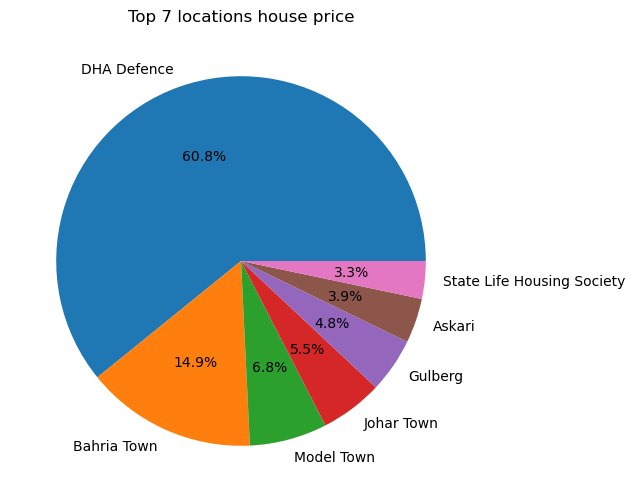

In [127]:
top_regions=price_sum.sort_values(ascending=False).head(7)
top_regions.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6))
plt.title("Top 7 locations house price")
plt.ylabel("")
plt.show()

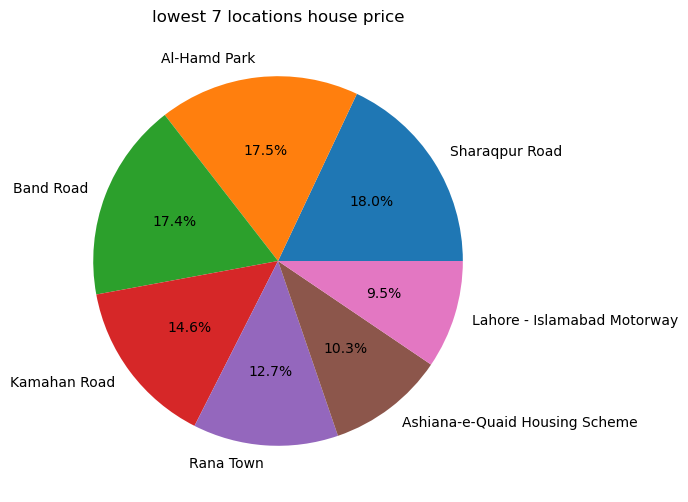

In [128]:
lowest_regions=price_sum.sort_values(ascending=False).tail(7)
lowest_regions.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6))
plt.title("lowest 7 locations house price")
plt.ylabel("")
plt.show()

In [129]:
# average of all house prices as per location
price_avg=lahore_cleaned_data.groupby("location")["price"].mean()
price_avg

location
Aashiana Road                             48.806122
Abdalians Cooperative Housing Society    402.038462
Airline Housing Society                  257.966667
Airport Road                             100.363636
Al Faisal Town                            79.391892
                                            ...    
Walled City                              183.660000
Walton Road                              104.015357
Wapda Town                               246.824861
Zaheer Villas                             78.225806
Zaitoon - New Lahore City                 77.925926
Name: price, Length: 157, dtype: float64

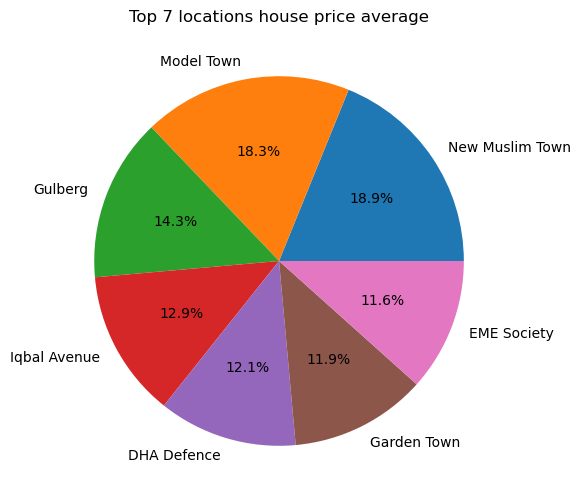

In [130]:
price_avg_top_regions=price_avg.sort_values(ascending=False).head(7)
price_avg_top_regions.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6))
plt.title("Top 7 locations house price average")
plt.ylabel("")
plt.show()

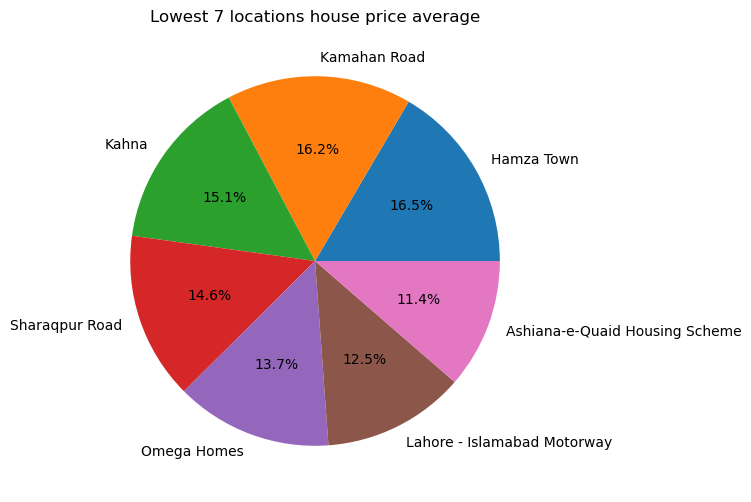

In [131]:
price_avg_lowest_regions=price_avg.sort_values(ascending=False).tail(7)
price_avg_lowest_regions.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6))
plt.title("Lowest 7 locations house price average")
plt.ylabel("")
plt.show()

In [132]:
# average of all prices per marla as per location
price_per_marla_avg=lahore_cleaned_data.groupby("location")["price_per_marla"].mean()
price_per_marla_avg

location
Aashiana Road                            15.343780
Abdalians Cooperative Housing Society    23.622884
Airline Housing Society                  19.338889
Airport Road                             18.187266
Al Faisal Town                           19.624187
                                           ...    
Walled City                              46.695534
Walton Road                              20.804371
Wapda Town                               21.834223
Zaheer Villas                            19.418866
Zaitoon - New Lahore City                16.241270
Name: price_per_marla, Length: 157, dtype: float64

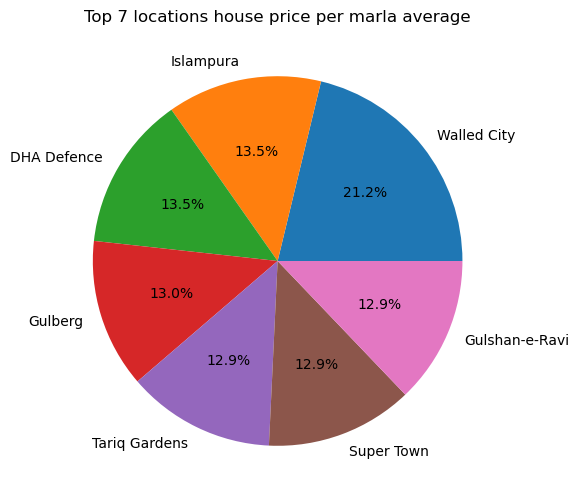

In [133]:
price_per_marla_avg_top_regions=price_per_marla_avg.sort_values(ascending=False).head(7)
price_per_marla_avg_top_regions.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6))
plt.title("Top 7 locations house price per marla average")
plt.ylabel("")
plt.show()

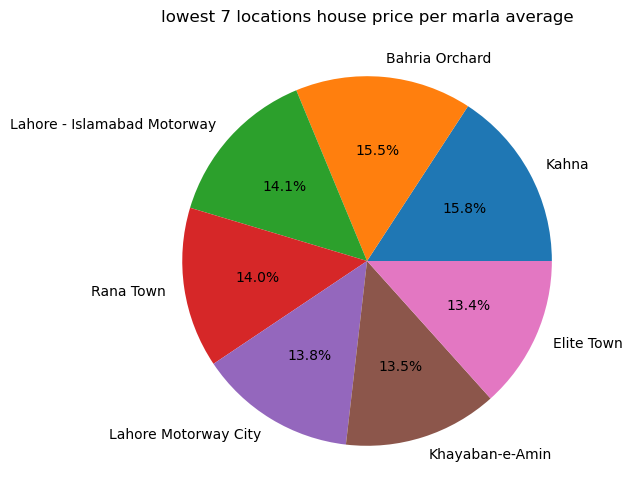

In [134]:
price_per_marla_avg_lowest_regions=price_per_marla_avg.sort_values(ascending=False).tail(7)
price_per_marla_avg_lowest_regions.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6))
plt.title("lowest 7 locations house price per marla average")
plt.ylabel("")
plt.show()

#### Effect of bedrooms on price

bedrooms
0     386.209348
1      43.327713
2      65.826895
3     114.248404
4     205.174573
5     374.237354
6     499.935805
7     583.206632
8     646.177914
9     808.128205
10    842.350877
11    938.333333
Name: price, dtype: float64


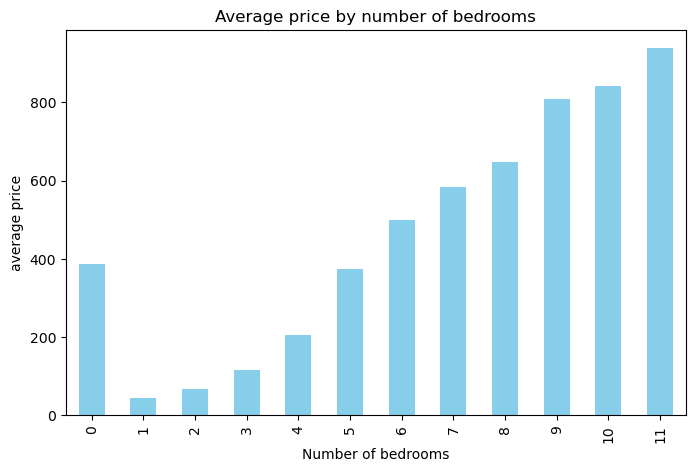

In [135]:
bedroom_avg_price=lahore_cleaned_data.groupby("bedrooms")["price"].mean()
print(bedroom_avg_price)
bedroom_avg_price.plot(kind="bar", figsize=(8,5), color="skyblue")
plt.title("Average price by number of bedrooms")
plt.xlabel("Number of bedrooms")
plt.ylabel("average price")
plt.show()

#### Effect of baths on price

baths
1      42.344402
2      64.171107
3     111.103067
4     163.360326
5     282.676990
6     412.568627
7     443.570565
8     641.315722
9     776.040000
10    979.695238
12    900.000000
Name: price, dtype: float64


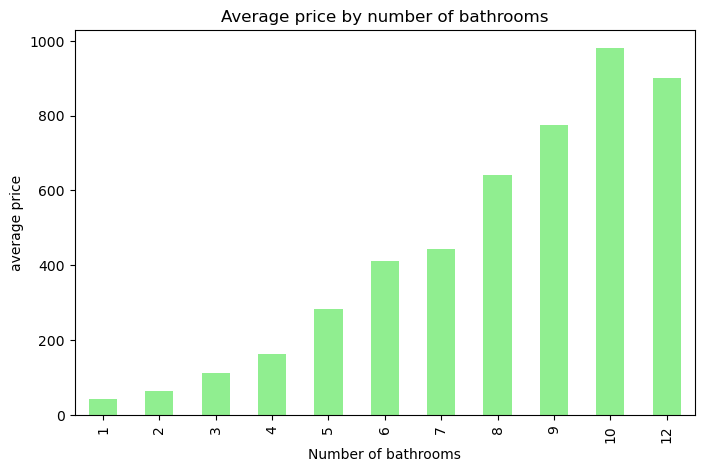

In [136]:
bath_avg_price=lahore_cleaned_data.groupby("baths")["price"].mean()
print(bath_avg_price)
bath_avg_price.plot(kind="bar", figsize=(8,5), color="lightgreen")
plt.title("Average price by number of bathrooms")
plt.xlabel("Number of bathrooms")
plt.ylabel("average price")
plt.show()

#### House search code

In [144]:
location_name="Aashiana Road"
beds= 2
baths=2
min_price=20
max_price=40
area=4
result=lahore_cleaned_data[(lahore_cleaned_data["location"]==location_name) &
   (lahore_cleaned_data["bedrooms"]==beds)&
    (lahore_cleaned_data["baths"]==baths) &
    (lahore_cleaned_data["price"]>=min_price) &
    (lahore_cleaned_data["price"]<=max_price) &
    (lahore_cleaned_data["area in marla"]==area)]
print(result)

      property_id  price       location    city  baths  area in marla  \
1338      8127142   32.0  Aashiana Road  Lahore      2            4.0   

      bedrooms  price_per_marla  
1338         2              8.0  


## Islamabad data analysis

In [60]:
Islamabad_cleaned_data=cleaned_data[cleaned_data['city']=='Islamabad']
Islamabad_cleaned_data

,property_id,price,location,city,baths,area in marla,bedrooms
0,237062,100.00,G-10,Islamabad,2,4.0,2
1,346905,69.00,E-11,Islamabad,3,5.6,3
2,386513,165.00,G-15,Islamabad,6,8.0,5
3,656161,435.00,Bani Gala,Islamabad,4,40.0,4
4,841645,70.00,DHA Defence,Islamabad,3,8.0,3
...,...,...,...,...,...,...,...
119117,17356173,7.00,F-7,Islamabad,9,40.0,8
119118,17356192,1.15,I-8,Islamabad,3,20.0,4
119119,17356220,0.45,PWD Housing Scheme,Islamabad,3,12.0,3
119120,17356245,4.00,F-7,Islamabad,6,26.0,5


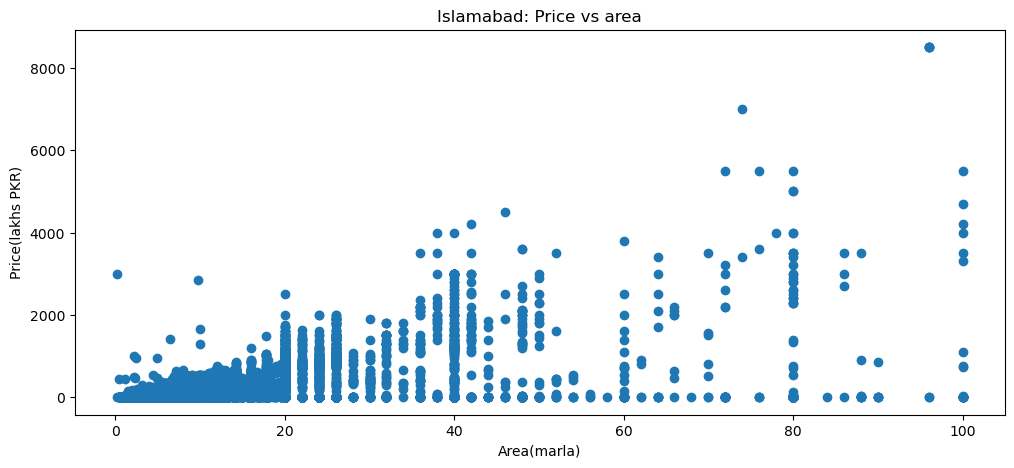

In [61]:
plt.figure(figsize=(12,5))
plt.scatter(Islamabad_cleaned_data['area in marla'],Islamabad_cleaned_data['price'])
plt.xlabel('Area(marla)')
plt.ylabel('Price(lakhs PKR)')
plt.title("Islamabad: Price vs area")
plt.show()

In [62]:
# top 5 expensive locations in Islamabad
top_5_expensive_I=(Islamabad_cleaned_data.groupby(["location"])["price"].mean().sort_values(ascending=False).head(5))
top_5_expensive_I

location
E-7                   511.358000
G-6                   398.622417
F-7                   350.735249
F-6                   348.690233
Emaar Canyon Views    284.850968
Name: price, dtype: float64

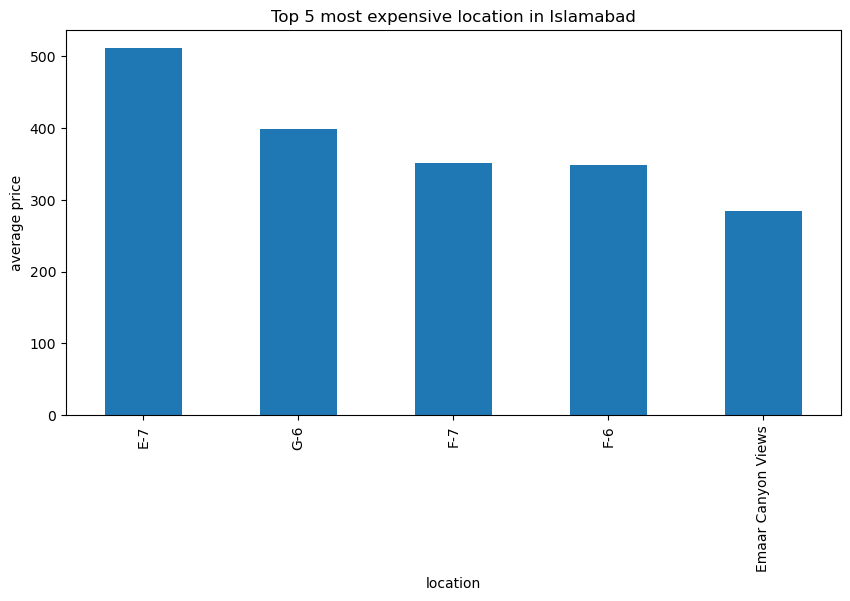

In [63]:
top_5_expensive_I.plot(kind="bar", figsize=(10,5))
plt.title("Top 5 most expensive location in Islamabad")
plt.ylabel("average price")
plt.show()

In [64]:
top_5_cheapest_I=(Islamabad_cleaned_data.groupby(["location"])["price"].mean().sort_values().head(5))
top_5_cheapest_I

location
G-16             31.146429
Lehtarar Road    32.227368
Shehzad Town     32.922424
Burma Town       37.415472
Koral Chowk      39.136667
Name: price, dtype: float64

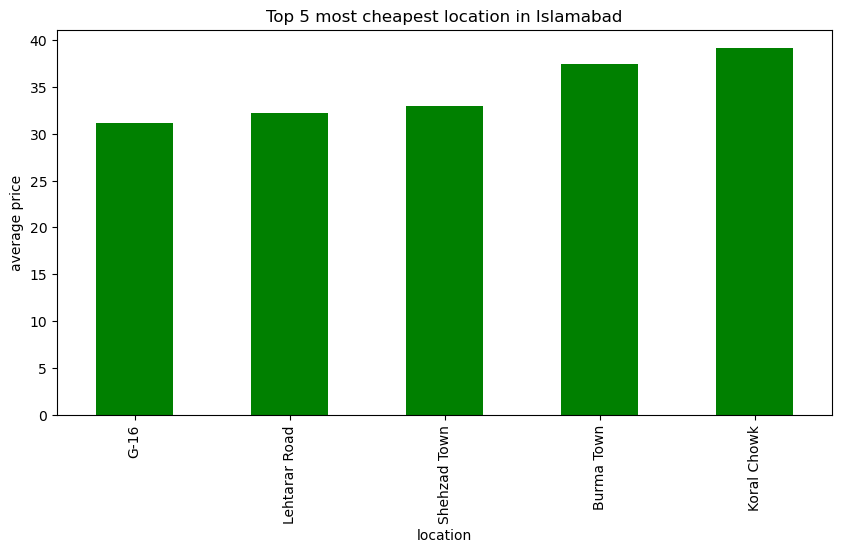

In [65]:
top_5_cheapest_I.plot(kind="bar", figsize=(10,5), color="green")
plt.title("Top 5 most cheapest location in Islamabad")
plt.ylabel("average price")
plt.show()

In [66]:
# average price per location and highest location in Islamabad
location_price=Islamabad_cleaned_data.groupby("location")["price"].mean()
# get highest and lowest price location
highest_location=location_price.idxmax()
lowest_location=location_price.idxmin()
# average price of one canal house
one_canal_high=Islamabad_cleaned_data[(Islamabad_cleaned_data["location"]==highest_location) & (Islamabad_cleaned_data["area in marla"]==20)]["price"].mean()
one_canal_low=Islamabad_cleaned_data[(Islamabad_cleaned_data["location"]==lowest_location) & (Islamabad_cleaned_data["area in marla"]==20)]["price"].mean()
print("Highest price location:", highest_location, one_canal_high)
print("lowest price location:", lowest_location, one_canal_low)

Highest price location: E-7 53.9469387755102
lowest price location: G-16 36.23571428571429


In [67]:
# average price per marla and highest location
Islamabad_cleaned_data["price_per_marla"]=(Islamabad_cleaned_data["price"]/Islamabad_cleaned_data["area in marla"])
location_ppm=Islamabad_cleaned_data.groupby("location")["price_per_marla"].mean()
highest_location=location_ppm.idxmax()
highest_price=location_ppm.max()
lowest_location=location_ppm.idxmin()
lowest_price=location_ppm.min()
print(f"Highest price per marla: {highest_location}: {highest_price:.2f}")
print(f"lowest price per marla: {lowest_location}: {lowest_price:.2f}")

Highest price per marla: Kashmir Highway: 41.09
lowest price per marla: G-16: 2.53


C:\Users\shake\AppData\Local\Temp\ipykernel_13928\1915871727.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Islamabad_cleaned_data["price_per_marla"]=(Islamabad_cleaned_data["price"]/Islamabad_cleaned_data["area in marla"])


In [68]:
# average price per marla at each location
Islamabad_cleaned_data["price_per_marla"]=(Islamabad_cleaned_data["price"]/Islamabad_cleaned_data["area in marla"])
location_ppm_df=Islamabad_cleaned_data.groupby("location")["price_per_marla"].mean().reset_index()
location_ppm_df.columns=["location","Average price per marla"]
location_ppm_df=location_ppm_df.sort_values(by="Average price per marla",ascending=False)
location_ppm_df

C:\Users\shake\AppData\Local\Temp\ipykernel_13928\4290238231.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Islamabad_cleaned_data["price_per_marla"]=(Islamabad_cleaned_data["price"]/Islamabad_cleaned_data["area in marla"])


,location,Average price per marla
53,Kashmir Highway,41.091804
26,F-8,25.063697
52,Karakoram Diplomatic Enclave,24.190711
28,Faisal Town - F-18,19.394577
16,Diplomatic Enclave,18.389474
...,...,...
58,Lehtarar Road,5.811713
63,PWD Housing Scheme,5.606410
69,Shehzad Town,3.984579
0,7th Avenue,3.773351


In [69]:
Islamabad_cleaned_data[['price', 'area in marla','baths','bedrooms', 'price_per_marla']].corr()

,price,area in marla,baths,bedrooms,price_per_marla
price,1.000000,0.358657,0.380214,0.384788,0.163510
area in marla,0.358657,1.000000,0.494864,0.494886,-0.011630
baths,0.380214,0.494864,1.000000,0.929176,0.060192
bedrooms,0.384788,0.494886,0.929176,1.000000,0.060586
price_per_marla,0.163510,-0.011630,0.060192,0.060586,1.000000


### Price of one canal home in Islamabad different areas

In [70]:
one_canal=Islamabad_cleaned_data[Islamabad_cleaned_data["area in marla"]==20]
one_canal

,property_id,price,location,city,baths,area in marla,bedrooms,price_per_marla
6,937975,270.00,Korang Town,Islamabad,8,20.0,8,13.5000
8,1402466,500.00,DHA Defence,Islamabad,7,20.0,7,25.0000
9,1418706,400.00,F-11,Islamabad,5,20.0,5,20.0000
17,2234957,269.00,B-17,Islamabad,6,20.0,6,13.4500
28,858689,1.10,DHA Defence,Islamabad,5,20.0,5,0.0550
...,...,...,...,...,...,...,...,...
119109,17355548,0.50,DHA Defence,Islamabad,3,20.0,3,0.0250
119110,17355550,0.55,DHA Defence,Islamabad,3,20.0,3,0.0275
119111,17355554,1.05,DHA Defence,Islamabad,6,20.0,6,0.0525
119112,17355559,0.40,DHA Defence,Islamabad,3,20.0,3,0.0200


### G-16 prices compare to other locations

In [72]:
# G-16 Housing Scheme prices (price per location) compare to others
G_16_Housing_Scheme_price=Islamabad_cleaned_data[Islamabad_cleaned_data["location"]=="G-16"]["price"].mean()
overall_avg=Islamabad_cleaned_data["price"].mean()
print("G-16 average price:", G_16_Housing_Scheme_price)
print("Overall average average price:", overall_avg)

G-16 average price: 31.146428571428576
Overall average average price: 130.01188753285103


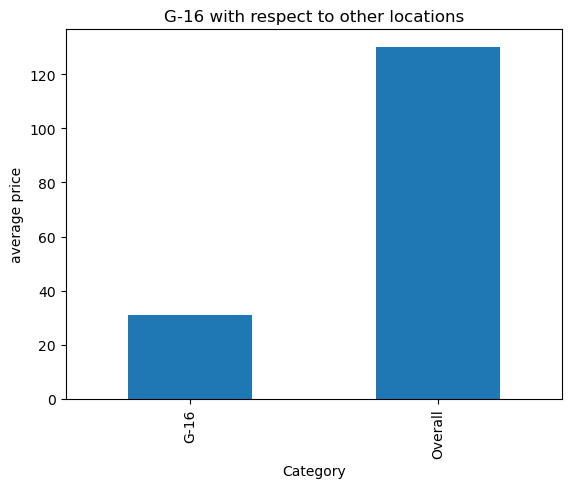

In [73]:
comparison=pd.DataFrame({
    "Category":["G-16", "Overall"],
    "Average price": [G_16_Housing_Scheme_price, overall_avg]})
comparison.plot(kind="bar", x="Category", y="Average price",legend=False)
plt.title("G-16 with respect to other locations")
plt.ylabel("average price")
plt.show()

### G-16 prices(prices per marla) compare to other locations

In [74]:
# sum of all house prices as per location
price_sum=Islamabad_cleaned_data.groupby("location")["price"].sum()
price_sum

location
7th Avenue               3310.4900
9th Avenue               1242.5800
Ali Pur                  1542.9000
Alipur Farash            1526.6800
Arsalan Town             1065.6000
                           ...    
Soan Garden             47855.8396
Taramrri                 1301.9850
Tarlai                   1150.6700
Tarnol                   2056.3350
Zaraj Housing Scheme     5310.7920
Name: price, Length: 75, dtype: float64

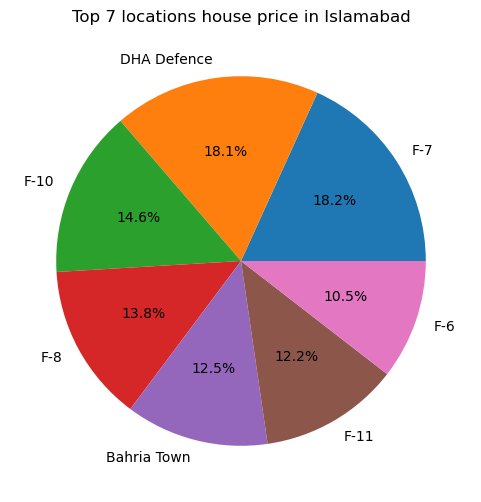

In [76]:
top_regions=price_sum.sort_values(ascending=False).head(7)
top_regions.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6))
plt.title("Top 7 locations house price in Islamabad")
plt.ylabel("")
plt.show()

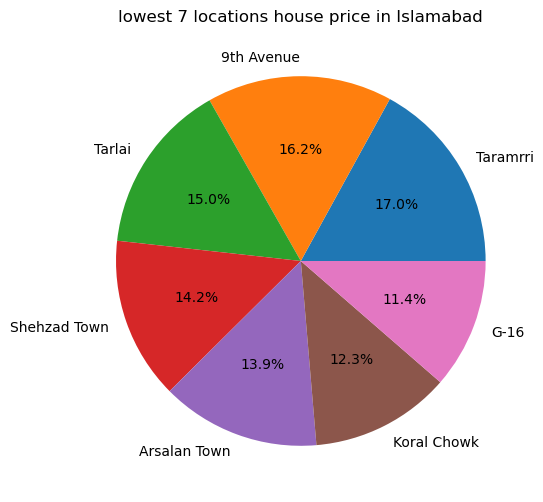

In [77]:
lowest_regions=price_sum.sort_values(ascending=False).tail(7)
lowest_regions.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6))
plt.title("lowest 7 locations house price in Islamabad")
plt.ylabel("")
plt.show()

In [78]:
# average of all house prices as per location
price_avg=Islamabad_cleaned_data.groupby("location")["price"].mean()
price_avg

location
7th Avenue               84.884359
9th Avenue               51.774167
Ali Pur                  49.770968
Alipur Farash            52.644138
Arsalan Town             48.436364
                           ...    
Soan Garden              77.062544
Taramrri                 39.454091
Tarlai                   39.678276
Tarnol                   64.260469
Zaraj Housing Scheme    104.133176
Name: price, Length: 75, dtype: float64

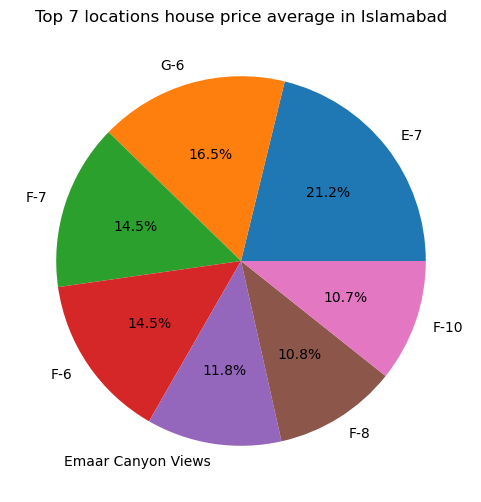

In [79]:
price_avg_top_regions=price_avg.sort_values(ascending=False).head(7)
price_avg_top_regions.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6))
plt.title("Top 7 locations house price average in Islamabad")
plt.ylabel("")
plt.show()

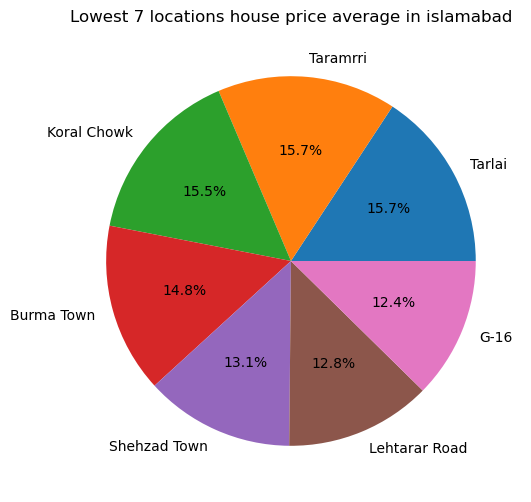

In [80]:
price_avg_lowest_regions=price_avg.sort_values(ascending=False).tail(7)
price_avg_lowest_regions.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6))
plt.title("Lowest 7 locations house price average in islamabad")
plt.ylabel("")
plt.show()

In [81]:
# average of all prices per marla as per location
price_per_marla_avg=Islamabad_cleaned_data.groupby("location")["price_per_marla"].mean()
price_per_marla_avg

location
7th Avenue               3.773351
9th Avenue               6.517345
Ali Pur                  8.719593
Alipur Farash           11.264261
Arsalan Town             9.968128
                          ...    
Soan Garden              9.322702
Taramrri                 8.998445
Tarlai                   8.967985
Tarnol                   6.786666
Zaraj Housing Scheme    11.217514
Name: price_per_marla, Length: 75, dtype: float64

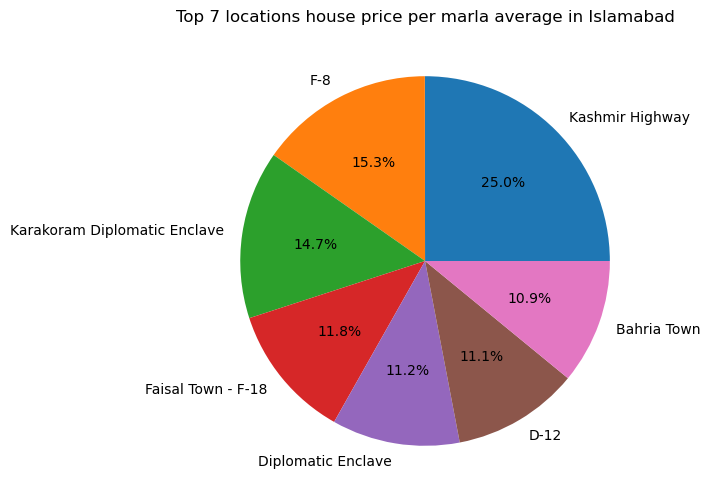

In [82]:
price_per_marla_avg_top_regions=price_per_marla_avg.sort_values(ascending=False).head(7)
price_per_marla_avg_top_regions.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6))
plt.title("Top 7 locations house price per marla average in Islamabad")
plt.ylabel("")
plt.show()

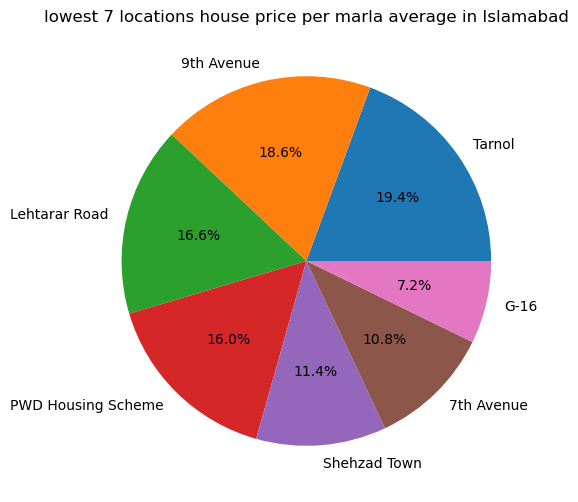

In [83]:
price_per_marla_avg_lowest_regions=price_per_marla_avg.sort_values(ascending=False).tail(7)
price_per_marla_avg_lowest_regions.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6))
plt.title("lowest 7 locations house price per marla average in Islamabad")
plt.ylabel("")
plt.show()

### Effect of bedrooms on price

bedrooms
0      126.829467
1       23.605203
2       26.091202
3       37.319504
4      123.726334
5      239.046573
6      282.358971
7      424.796064
8      425.787225
9      575.817425
10     477.623161
11     530.845522
12    2505.000000
14       6.500000
18       5.500000
Name: price, dtype: float64


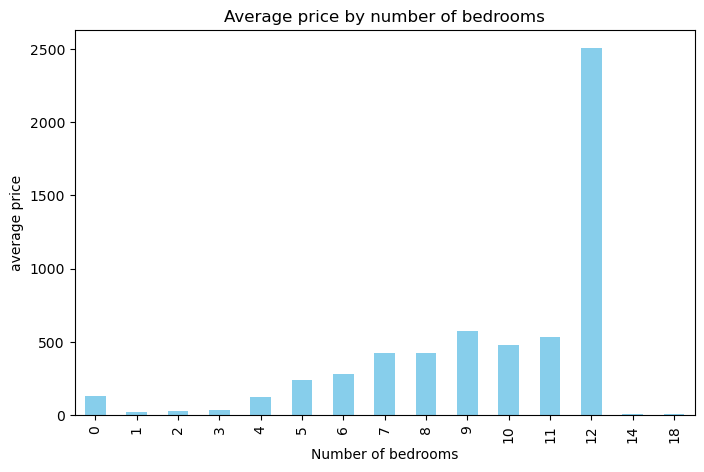

In [84]:
bedroom_avg_price=Islamabad_cleaned_data.groupby("bedrooms")["price"].mean()
print(bedroom_avg_price)
bedroom_avg_price.plot(kind="bar", figsize=(8,5), color="skyblue")
plt.title("Average price by number of bedrooms")
plt.xlabel("Number of bedrooms")
plt.ylabel("average price")
plt.show()

### Effect of bath on price

baths
1      23.123322
2      26.703589
3      37.488682
4      94.402273
5     208.789532
6     255.506374
7     315.388072
8     468.351737
9     388.610029
10    594.928833
11    612.500000
12    665.650000
13      3.000000
14      7.000000
Name: price, dtype: float64


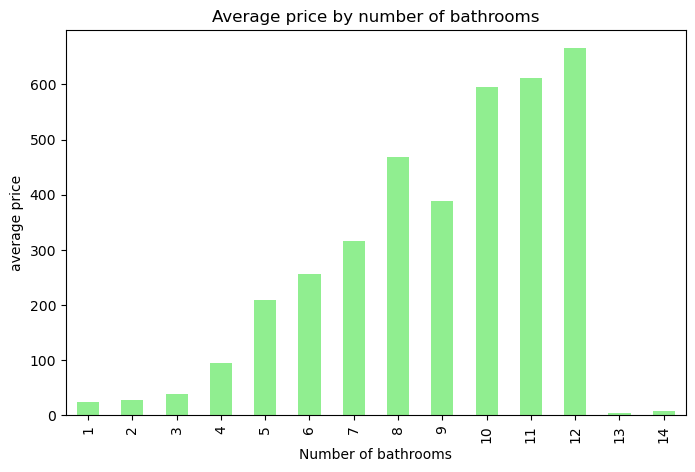

In [85]:
bath_avg_price=Islamabad_cleaned_data.groupby("baths")["price"].mean()
print(bath_avg_price)
bath_avg_price.plot(kind="bar", figsize=(8,5), color="lightgreen")
plt.title("Average price by number of bathrooms")
plt.xlabel("Number of bathrooms")
plt.ylabel("average price")
plt.show()

### House search code

In [111]:
location_name="Korang Town"
beds= 8
baths=8
min_price=10
max_price=300
area=20
result=Islamabad_cleaned_data[(Islamabad_cleaned_data["location"]==location_name) &
    (Islamabad_cleaned_data["bedrooms"]==beds)&
    (Islamabad_cleaned_data["baths"]==baths) &
    (Islamabad_cleaned_data["price"]>=min_price) &
    (Islamabad_cleaned_data["price"]<=max_price) &
    (Islamabad_cleaned_data["area in marla"]==area)]
print(result)

   property_id  price     location       city  baths  area in marla  bedrooms  \
6       937975  270.0  Korang Town  Islamabad      8           20.0         8   

   price_per_marla  
6             13.5  
